## NRI Data Check
Access Data from past and current versions (2020,2021,2023,2025)\
Identify and isolate relevant columns, basic exploration, generate summary score for YoY risk index


In [ ]:
import pandas as pd
from arcgis.features import FeatureLayer
import urllib3
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns

## Switch to read .csv if needed (saved from previous version on github)

# 1. Suppress SSL Warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.simplefilter("ignore", UserWarning)

def fetch_nri_by_url(service_url, version_label):
    """
    Fetches data directly via REST URL to bypass Item ID retirement issues.
    """
    print(f"Connecting to {version_label}...")
    try:
        # Initialize the layer directly from the URL
        # We set verify_cert=False to stop the SSL noise in restricted environments
        layer = FeatureLayer(service_url)
        
        # Query the data. We use 'out_fields="*"' to get all columns.
        # We also request result_type='standard' to help with the decompression issue.
        query_result = layer.query(where="1=1", out_fields="*", return_geometry=False)
        
        # Convert to DataFrame
        df = query_result.sdf
        
        # Clean up column names (ArcGIS sometimes adds extra prefixes)
        df.columns = [c.upper() for c in df.columns]
        
        print(f"Successfully imported {len(df)} records for {version_label}.")
        return df
    except Exception as e:
        print(f"Failed to fetch {version_label}: {e}")
        return None

# --- REST Service URLs (Updated for 2020-2023 Snapshots) ---
# Note: These URLs point to the persistent FeatureServer endpoints 
# managed by FEMA or the Resilience/Climate Hubs.

urls = {
    "2020_v1_17": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_v117/FeatureServer/0",
    "2021_v1_18": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/NRI_Counties_Prod_v1181_view/FeatureServer/0",
    "2023_v1_19": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties_(March_2023)/FeatureServer/0",
    "2025_v1_20": "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/National_Risk_Index_Counties/FeatureServer/0"
}

# --- Import Data ---
nri_2020 = fetch_nri_by_url(urls["2020_v1_17"], "NRI 2020 (v1.17)")
nri_2021 = fetch_nri_by_url(urls["2021_v1_18"], "NRI 2021 (v1.18)")
nri_2023 = fetch_nri_by_url(urls["2023_v1_19"], "NRI 2023 (v1.19)")
nri_2025 = fetch_nri_by_url(urls["2025_v1_20"], "NRI 2025 (v1.20)")

pd.set_option('display.max_columns', 50)
pd.options.display.float_format = '{:,.2f}'.format

Connecting to NRI 2020 (v1.17)...
Successfully imported 3142 records for NRI 2020 (v1.17).
Connecting to NRI 2021 (v1.18)...
Successfully imported 3142 records for NRI 2021 (v1.18).
Connecting to NRI 2023 (v1.19)...
Successfully imported 3231 records for NRI 2023 (v1.19).
Connecting to NRI 2025 (v1.20)...
Successfully imported 3232 records for NRI 2025 (v1.20).


In [4]:
print(nri_2020.shape)
nri_2020.iloc[:,0:50].head()

(3142, 353)


,FID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_SCORE,RISK_RATNG,RISK_NPCTL,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_NPCTL,EAL_SPCTL,EAL_VALT,EAL_VALB,EAL_VALP,EAL_VALPE,EAL_VALA,SOVI_SCORE,SOVI_RATNG,SOVI_NPCTL,SOVI_SPCTL,SOVI_VALUE,RESL_SCORE,RESL_RATNG,RESL_NPCTL,RESL_SPCTL,RESL_VALUE,AVLN_EVNTS,AVLN_AFREQ,AVLN_EXPB,AVLN_EXPP,AVLN_EXPPE,AVLN_EXPT,AVLN_HLRB,AVLN_HLRP,AVLN_HLRR,AVLN_EALB,AVLN_EALP,AVLN_EALPE,AVLN_EALT,AVLN_EALS
0,1769,C18009,Indiana,IN,18,Blackford,County,009,18009,12766,1361601000.0,63476000.0,165.079701,7.82786,Very Low,28.707829,34.782609,8.543025,Very Low,15.849777,7.608696,1787633.51925,555629.307892,0.136921,1013214.25757,218789.953785,43.121797,Relatively Moderate,70.273711,93.478261,1.21,54.3718,Relatively Moderate,46.721833,18.478261,2.71859,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Not Applicable,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
1,1765,C18001,Indiana,IN,18,Adams,County,001,18001,34387,3490483000.0,283136000.0,339.028241,7.924503,Very Low,29.949077,38.043478,10.056026,Very Low,27.593889,16.304348,2621961.3815,759792.881873,0.191152,1414526.91262,447641.587011,39.180134,Relatively Moderate,54.010185,78.26087,0.21,57.442198,Relatively High,82.431572,93.478261,2.87211,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Not Applicable,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
2,1750,C17175,Illinois,IL,17,Stark,County,175,17175,5994,718195000.0,117015000.0,288.079,7.978802,Very Low,30.649268,27.45098,10.56461,Relatively Low,32.081477,11.764706,2951824.65336,1067060.30057,0.100435,743218.09703,1141546.25576,37.564052,Relatively Moderate,46.912794,59.803922,-0.2,57.4646,Relatively High,82.845321,66.666667,2.87323,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Not Applicable,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
3,1748,C17171,Illinois,IL,17,Scott,County,171,17171,5355,565204000.0,84659000.0,250.912723,8.611122,Very Low,36.982813,33.333333,11.474278,Relatively Low,40.356461,17.647059,3608757.24196,623354.423841,0.19703,1458020.90477,1527381.91335,36.815136,Relatively Moderate,43.634628,53.921569,-0.39,56.6786,Relatively High,73.806493,41.176471,2.83393,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Not Applicable,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
4,1745,C17165,Illinois,IL,17,Saline,County,165,17165,24913,2641964000.0,73568000.0,379.829979,16.667597,Relatively Moderate,88.383195,94.117647,17.097359,Relatively Moderate,78.612349,75.490196,9912467.98745,5404290.69302,0.539805,3994554.28071,513623.013716,46.314545,Relatively High,81.413113,97.058824,2.02,54.9024,Relatively Moderate,53.055379,11.764706,2.74512,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Not Applicable,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0


In [5]:
nri_2020.head(50).columns

Index(['FID', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'POPULATION',
       ...
       'WNTW_EALPE', 'WNTW_EALT', 'WNTW_EALS', 'WNTW_EALR', 'WNTW_RISKS',
       'WNTW_RISKR', 'NRI_VER', 'SHAPE_LENG', 'SHAPE__AREA', 'SHAPE__LENGTH'],
      dtype='object', length=353)

In [6]:
print(nri_2021.shape)
nri_2021.iloc[:,0:22].head()

(3142, 367)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_SCORE,RISK_RATNG,RISK_NPCTL,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_NPCTL,EAL_SPCTL,EAL_VALT
0,2,C21117,Kentucky,KY,21,Kenton,County,117,21117,159720,18773375000.0,5390000.0,160.213975,10.449057,Relatively Low,61.489497,79.166667,16.837131,Relatively Moderate,80.267346,94.166667,8818275.450139
1,8,C21129,Kentucky,KY,21,Lee,County,129,21129,7887,516747000.0,1392000.0,208.857132,4.937158,Very Low,10.630172,5.833333,7.048453,Very Low,12.316996,5.833333,946889.10882
2,14,C21143,Kentucky,KY,21,Lyon,County,143,21143,8314,903331000.0,6662000.0,213.840583,6.622276,Very Low,24.315722,25.833333,9.694572,Very Low,33.290898,40.0,2072716.447941
3,15,C21145,Kentucky,KY,21,McCracken,County,145,21145,65565,8567841000.0,28923000.0,248.743868,19.123642,Relatively Moderate,92.552514,99.166667,22.194551,Relatively Moderate,90.897518,98.333333,18805779.486095
4,22,C21157,Kentucky,KY,21,Marshall,County,157,21157,31448,3277271000.0,51379000.0,301.266357,11.233432,Relatively Low,67.568428,82.5,14.876506,Relatively Low,71.865054,88.333333,6319982.506463


In [7]:
print(nri_2023.shape)
nri_2023.iloc[:,0:22].head()

(3231, 467)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB
0,253,C08014,Colorado,CO,08,Broomfield,County,014,08014,74051,14509079514.0,703703.0,33.88681,11010997.254123,67.292396,Relatively Low,82.8125,74.404209,Relatively Low,84.375,13614278.287483,8048787.971599
1,321,C11001,District of Columbia,DC,11,District of Columbia,<NA>,001,11001,688888,385180728350.0,0.0,69.040096,54099286.951878,91.568565,Relatively Moderate,100.0,92.014856,Relatively Moderate,100.0,50896637.058529,33158911.627493
2,341,C12041,Florida,FL,12,Gilchrist,County,041,12041,17826,2020926195.0,102942683.0,358.826408,6140616.37451,49.061406,Relatively Low,5.970149,41.658929,Very Low,4.477612,4360783.689701,2802318.327003
3,384,C12125,Florida,FL,12,Union,County,125,12125,16088,1669580921.0,8834650.0,252.273046,5116478.272612,43.07986,Very Low,2.985075,38.409161,Very Low,2.985075,4009725.950192,3392492.498534
4,391,C13005,Georgia,GA,13,Bacon,County,005,13005,11116,2434591152.0,72462872.0,288.707846,6038367.786058,48.743239,Relatively Low,52.830189,37.852058,Very Low,50.943396,3942675.776085,2562981.228348


In [8]:
print(nri_2025.shape)
nri_2025.iloc[:,0:22].head()

(3232, 467)


,OBJECTID,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB
0,225,C06075,California,CA,06,San Francisco,County,075,06075,873808,173852174526.0,42355903.0,234.255013,915983769.771988,99.522901,Very High,99.522901,99.597772,Relatively High,86.206897,853429992.674755,539559891.569997
1,270,C08047,Colorado,CO,08,Gilpin,County,047,08047,5803,1799265140.0,291994.0,151.904533,3622102.357588,6.361323,Very Low,6.361323,10.891089,Very Low,18.75,4503801.519584,3903033.55334
2,394,C13011,Georgia,GA,13,Banks,County,011,13011,18018,3830670950.0,218299789.0,236.772855,5617884.832526,12.40458,Very Low,12.40458,17.079208,Very Low,32.704403,5943369.970484,3549609.943071
3,395,C13013,Georgia,GA,13,Barrow,County,013,13013,83288,13453179051.0,46300672.0,164.577075,15107820.303437,45.610687,Relatively Low,45.610687,57.054455,Relatively Low,72.327044,18174614.757267,13795365.351176
4,400,C13023,Georgia,GA,13,Bleckley,County,023,13023,12537,2524500231.0,15968067.0,221.343543,8981662.601893,25.667939,Very Low,25.667939,19.956683,Very Low,37.735849,6599599.390071,2504893.426538


# Columns of interest:
State, county, population, 
bldg value, agricultural value, area, 
risk value (dollar amount), risk score (nat'l percentile ranking), risk rating (category), 
expected annual loss value (dollar amount), expected annual loss score (nat'l %), expected annual loss rating (category), 
social vulnerability score (nat'l %), social vulnerability rating (category),
Community resilience score (nat'l %), community resilience rating (category), community resilience value (index from source data), community risk factor

'STATEABBRV', 'COUNTY', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATING', 'EAL_VALT', 'EAL_SCORE', 'EAL_RATING', 'SOVI_SCORE', 'SOVI_RATING', 'RESL_SCORE', 'RESL_RATING', 'RESL_VALUE', 'CRF_VALUE'

20-21
'RISK_NPCTL', 'EAL_VALT', 'SOVI_VALUE', 'RESL_VALUE'

There are detailed fields for each disaster type, state level percent ranks, exp annual loss rate (dollars as % of bldgs, pop, agri), adjusted exp ann loss rate for social vulnerability and comm resil

# Note on Scores:
Scores in 2020 and 2021 were 1-100 relative index scores (although not national percentiles), where 2023 and 2025 have values that represent dollar amounts (meant to be an absolute indicator), and scores that are nat'l percentile rating 

Using the updated methodology, we can compute retroactive risk values for 2020 and 2021 by replicating their method with sovi_score, resl_score, and eal_valt

In [30]:
keep_cols_1 = ['NRI_ID',
            'STATEABBRV', 
             'COUNTY', 
             'POPULATION', 
             'BUILDVALUE', 
             'AGRIVALUE', 
             'AREA', 
             'RISK_SCORE', 
             'RISK_RATNG', 
             'RISK_NPCTL', 
             'EAL_SCORE', 
             'EAL_VALT', 
             'EAL_NPCTL', 
             'EAL_RATNG', 
             'SOVI_SCORE', 
             'SOVI_RATNG', 
             'SOVI_VALUE', 
             'RESL_SCORE', 
             'RESL_RATNG', 
             'RESL_VALUE']

keep_cols_2 = ['NRI_ID',
               'STATEABBRV', 
             'COUNTY', 
             'POPULATION', 
             'BUILDVALUE', 
             'AGRIVALUE', 
             'AREA',
             'RISK_VALUE', 
             'RISK_SCORE', 
             'RISK_RATNG', 
             'EAL_SCORE', 
             'EAL_VALT',  
             'EAL_RATNG', 
             'SOVI_SCORE', 
             'SOVI_RATNG',  
             'RESL_SCORE', 
             'RESL_RATNG', 
             'RESL_VALUE',
             'CRF_VALUE']

nri_20 = nri_2020[keep_cols_1]
nri_20.columns = nri_20.columns.str.lower()

nri_21 = nri_2021[keep_cols_1]
nri_21.columns = nri_21.columns.str.lower()

nri_23 = nri_2023[keep_cols_2]
nri_23.columns = nri_23.columns.str.lower()

nri_25 = nri_2025[keep_cols_2]
nri_25.columns = nri_25.columns.str.lower()

print('Shapes:\n'+'='*50)
print('2020', nri_20.shape)
print('2021', nri_21.shape)
print('2023', nri_23.shape)
print('2025', nri_25.shape)

Shapes:
2020 (3142, 20)
2021 (3142, 20)
2023 (3231, 19)
2025 (3232, 19)


Looks like **89** counties were added in **2023** and **1** more in **2025** for a total of **90**

In [31]:
# Adding state+county- nri_id ended up being better

nri_20.loc[:, "st_county"] = nri_20["stateabbrv"].str.cat(nri_20["county"], sep='_')
nri_21.loc[:, "st_county"] = nri_21["stateabbrv"].str.cat(nri_21["county"], sep='_')
nri_23.loc[:, "st_county"] = nri_23["stateabbrv"].str.cat(nri_23["county"], sep='_')
nri_25.loc[:, "st_county"] = nri_25["stateabbrv"].str.cat(nri_25["county"], sep='_')

/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/3913897111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20.loc[:, "st_county"] = nri_20["stateabbrv"].str.cat(nri_20["county"], sep='_')
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/3913897111.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21.loc[:, "st_county"] = nri_21["stateabbrv"].str.cat(nri_21["county"], sep='_')
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/3913897111.py:5: Sett

20/21 'risk_score' is the old methodology (unitless, 0-100). 23/25 'risk_score' is national percentile, formerly 'risk_npctl'

## Missing Values- Territories 

In [14]:
print("\nMissing values total 2020")
print(nri_20.isna().sum().sum())
print("\nMissing values total 2021")
print(nri_21.isna().sum().sum())
print("\nMissing values total 2023")
print(nri_23.isna().sum().sum())
print("\nMissing values total 2025")
print(nri_25.isna().sum().sum())



Missing values total 2020
0

Missing values total 2021
0

Missing values total 2023
450

Missing values total 2025
528


In [15]:
nri_23.isna().sum().sort_values(ascending=False)

crf_value     88
resl_value    88
resl_score    88
risk_value    88
risk_score    88
sovi_score    10
nri_id         0
eal_valt       0
resl_ratng     0
sovi_ratng     0
eal_ratng      0
eal_score      0
stateabbrv     0
risk_ratng     0
area           0
agrivalue      0
buildvalue     0
population     0
county         0
st_county      0
dtype: int64

In [16]:
nri_25.isna().sum().sort_values(ascending=False)

crf_value     88
resl_value    88
resl_score    88
risk_value    88
risk_score    88
sovi_score    88
nri_id         0
eal_valt       0
resl_ratng     0
sovi_ratng     0
eal_ratng      0
eal_score      0
stateabbrv     0
risk_ratng     0
area           0
agrivalue      0
buildvalue     0
population     0
county         0
st_county      0
dtype: int64

23 and 25 missing data for 88 rows which appear to be territories

In [17]:
nri_25[nri_25["crf_value"].isna()].stateabbrv.value_counts()

stateabbrv
PR    78
AS     3
MP     3
VI     3
GU     1
Name: count, dtype: Int64

In [18]:
nri_25[(nri_25["crf_value"].notna()) & (nri_25["stateabbrv"].isin(["PR","AS","MP","VI","GU"]))]

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value,st_county


In [33]:
nri_25 = nri_25.drop(nri_25[nri_25.stateabbrv.isin(["PR","AS","MP","VI","GU"])].index)
nri_23 = nri_23.drop(nri_23[nri_23.stateabbrv.isin(["PR","AS","MP","VI","GU"])].index)

print('2020', nri_20.shape)
print('2021', nri_21.shape)
print('2023',nri_23.shape)
print('2025',nri_25.shape)

2020 (3142, 21)
2021 (3142, 21)
2023 (3143, 20)
2025 (3144, 20)


In [34]:
# Recheck NaNs

print("\nMissing values total 2020")
print(nri_20.isna().sum().sum())
print("\nMissing values total 2021")
print(nri_21.isna().sum().sum())
print("\nMissing values total 2023")
print(nri_23.isna().sum().sum())
print("\nMissing values total 2025")
print(nri_25.isna().sum().sum())


Missing values total 2020
0

Missing values total 2021
0

Missing values total 2023
0

Missing values total 2025
0


### Investigate different row lengths 

In [35]:
print("Counties New in 21")
print(len(nri_21[~nri_21["nri_id"].isin(nri_20["nri_id"])]))
print("Counties Removed in 21")
print(len(nri_20[~nri_20["nri_id"].isin(nri_21["nri_id"])]))

Counties New in 21
0
Counties Removed in 21
0


In [36]:
print("Counties New in 23")
print(len(nri_23[~nri_23["nri_id"].isin(nri_21["nri_id"])]))
print("Counties Removed in 23")
print(len(nri_21[~nri_21["nri_id"].isin(nri_23["nri_id"])]))

Counties New in 23
2
Counties Removed in 23
1


In [37]:
# New counties in 23
nri_23[~nri_23["nri_id"].isin(nri_21["nri_id"])]

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value,st_county
3003,C02063,AK,Chugach,7011,842272076.0,0.0,15296.227862,1412609.258473,8.017817,Very Low,9.0684,1257506.947115,Very Low,23.52,Relatively Low,44.27,Relatively Moderate,2.573487,1.123341,AK_Chugach
3004,C02066,AK,Copper River,2596,481748878.0,0.0,25416.208556,531475.40059,2.036271,Very Low,1.578459,418396.837655,Very Low,41.790001,Relatively Moderate,70.809998,Relatively High,2.677363,1.270266,AK_Copper River


In [24]:
# Removed county in 23 (this was dissolved and split into the two separate census areas: https://en.wikipedia.org/wiki/Valdez%E2%80%93Cordova_Census_Area,_Alaska)
nri_21[~nri_21["nri_id"].isin(nri_23["nri_id"])]

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_score,risk_ratng,risk_npctl,eal_score,eal_valt,eal_npctl,eal_ratng,sovi_score,sovi_ratng,sovi_value,resl_score,resl_ratng,resl_value,st_county
2869,C02261,AK,Valdez-Cordova,9636,1513515000.0,0.0,34227.403524,8.590047,Relatively Low,45.257798,11.854596,3471855.703615,52.514322,Relatively Low,29.247142,Relatively Low,-2.31,46.633802,Very Low,2.33169,AK_Valdez-Cordova


In [25]:
print("Counties New in 25")
print(len(nri_25[~nri_25["nri_id"].isin(nri_23["nri_id"])]))
print("Counties Removed in 25")
print(len(nri_23[~nri_23["nri_id"].isin(nri_25["nri_id"])]))

Counties New in 25
9
Counties Removed in 25
8


Connecticut replaced 8 counties with 9 new counties in 2024
Roughly by area (and risk score comparison):
Old = New
- Northwest Hills = Litchfield
- Western Connecticut = Fairfield
- Greater Bridgeport = Fairfield
- South Central = New Haven
- Naugatuck Valley = New Haven (1/3 Litchfield)
- Lower Connecticut River Valley = Middlesex
- Capitol Planning Region = Hartford (1/3 Toland)
- Southeastern Connecticut = New London
- Northeastern Connecticut = Windham

### Addressing County Changes
Since we're interested in looking at risk over time, I propose we add special rules for CT and these AK counties that set the comparison value to the matching old county and for all others compare to themselves. 

So the removed counties won't have 23/25 data, but the new counties will have their 20, 21, 23 data backfilled by the counties they replaced. 

This means our join should end with 2025's 3144 counties, and the removed counties from past years will be represented in the counties that replaced them. 

In [38]:
nri_25[~nri_25["nri_id"].isin(nri_23["nri_id"])]

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value,st_county
999,C09120,CT,Greater Bridgeport,325728,61774895044.0,6896655.0,240.56448,113837585.017037,91.762087,Relatively Moderate,91.027228,104270035.378827,Relatively Moderate,45.260814,Relatively Moderate,59.860051,Relatively Moderate,2.509152,1.091757,CT_Greater Bridgeport
1599,C09150,CT,Northeastern Connecticut,95308,20961789246.0,63753853.0,568.841945,23885290.990671,62.754453,Relatively Low,75.247525,33196357.012469,Relatively Low,10.62341,Very Low,61.800254,Relatively High,2.515247,0.719515,CT_Northeastern Connecticut
1799,C09140,CT,Naugatuck Valley,450296,86822829491.0,59740558.0,425.824542,141561328.399362,93.193384,Relatively Moderate,93.657178,139882808.140155,Relatively Moderate,35.687023,Relatively Low,77.194656,Relatively High,2.566319,1.011999,CT_Naugatuck Valley
2199,C09160,CT,Northwest Hills,112433,31324671145.0,38060787.0,816.266403,43214764.618442,79.611959,Relatively Low,84.684406,53578076.134076,Relatively Moderate,12.754453,Very Low,76.685751,Relatively High,2.564836,0.806576,CT_Northwest Hills
2797,C09110,CT,Capitol,975267,211333505302.0,188125761.0,1056.745877,289261909.360871,97.360051,Relatively High,97.741337,302299864.611575,Relatively High,28.085242,Relatively Low,64.185751,Relatively High,2.524308,0.956871,CT_Capitol
2798,C09130,CT,Lower Connecticut River Valley,174152,40080990112.0,77166348.0,522.421907,53953220.392604,83.842239,Relatively Moderate,86.695545,62791593.262424,Relatively Moderate,17.875318,Very Low,90.362595,Very High,2.62374,0.859243,CT_Lower Connecticut River Valley
2799,C09170,CT,South Central Connecticut,570229,117109230899.0,102394050.0,625.834253,187866730.732457,95.133588,Relatively High,95.049505,173781420.098209,Relatively Moderate,45.197201,Relatively Moderate,79.707379,Relatively High,2.578027,1.081052,CT_South Central Connecticut
2998,C09180,CT,Southeastern Connecticut,280316,58884661758.0,166311192.0,688.594059,78418850.954773,88.645038,Relatively Moderate,89.263614,83462145.047653,Relatively Moderate,26.749364,Relatively Low,86.386768,Very High,2.604708,0.939574,CT_Southeastern Connecticut
2999,C09190,CT,Western Connecticut,620462,164503951315.0,44480977.0,654.571254,234522186.574628,96.278626,Relatively High,96.905941,259614003.311318,Relatively High,21.374046,Relatively Low,62.245547,Relatively High,2.516684,0.90335,CT_Western Connecticut


In [27]:
nri_23[~nri_23["nri_id"].isin(nri_25["nri_id"])]

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value,st_county
1575,C09015,CT,Windham,116384,22004051951.0,51717753.0,526.483013,11783782.55574,69.519567,Relatively Low,68.987929,10668434.284073,Relatively Low,47.990002,Relatively Moderate,66.93,Relatively High,2.662852,1.104547,CT_Windham
1977,C09013,CT,Tolland,149768,29286349576.0,61269343.0,421.339292,10894842.995041,67.069679,Relatively Low,72.082946,12224430.131885,Relatively Low,10.73,Very Low,78.010002,Relatively High,2.703643,0.891235,CT_Tolland
2163,C09007,CT,Middlesex,164179,33005173781.0,65467141.0,443.497429,18438232.494446,78.36462,Relatively Low,80.934695,19347495.245879,Relatively Low,18.43,Very Low,92.970001,Very High,2.78897,0.953004,CT_Middlesex
2349,C09009,CT,New Haven,864495,154054554545.0,128032379.0,870.771522,86029805.698488,94.463888,Relatively Moderate,94.676571,80397795.615645,Relatively Moderate,65.120003,Relatively High,82.529999,Very High,2.724345,1.070052,CT_New Haven
2548,C09003,CT,Hartford,898547,170789826905.0,107711671.0,758.194222,52778120.842067,91.473115,Relatively Moderate,91.891055,49999228.506224,Relatively Moderate,59.549999,Relatively Moderate,74.32,Relatively High,2.689877,1.055579,CT_Hartford
2758,C09005,CT,Litchfield,185062,43128751557.0,47185434.0,954.124674,23232068.46105,82.500795,Relatively Low,84.896317,24701195.174691,Relatively Moderate,15.12,Very Low,81.540001,Very High,2.719478,0.940524,CT_Litchfield
2944,C09011,CT,New London,268434,51626646542.0,155745711.0,779.75604,33233516.927006,87.368756,Relatively Moderate,88.177035,33116322.334123,Relatively Moderate,39.59,Relatively Low,88.160004,Very High,2.755666,1.003539,CT_New London
2945,C09001,CT,Fairfield,957322,202345538715.0,48252692.0,845.498527,108472972.086488,95.450207,Relatively High,95.914578,108362436.826759,Relatively High,61.84,Relatively High,66.68,Relatively High,2.662064,1.00102,CT_Fairfield


## To do
- Figure out risk value: ✅
  - Divide sovi score/comm resil score. transform to nat'l percentile✅
  - Apply Probability Point Function- triangular distribution with min 0.5, mode 1, max 2✅
  - Recalculate for 25 to ensure correct methodology✅
  - Sanity check against old score✅
- Arrange multi-year df in friendly format
- calculate (or write funtion) for change over time (takes multiple years, difference between max year value and min year)
- Community resilience score methodology change 25 administration- compare counties to 23, anything obvious
- Interesting correlations: how do we interpret or use zillow data to explore the effect of property prices to risk calculation (commercial vs personal??). Almost a normalization based on property values. physical risk vs monetary. Or understand relationship
2/6
- sovi, resil, crf values to Dave to add to regression
- Investigate massive increase in risk values 23, 25
- Investigate top counties for driving overall stats 

## Community Risk Factor Calc

In [40]:
from scipy import stats

In [41]:
# Get initial ratio from sovi_score / resl_score
nri_20['comm_risk_ratio_score'] = (
    nri_20['sovi_score'] / nri_20['resl_score']
)

#replicate for 21
nri_21['comm_risk_ratio_score'] = (
    nri_21['sovi_score'] / nri_21['resl_score']
)

print("\n" + "="*70)
print("STEP 1: Community Risk Ratio Calculation")
print("="*70)
print(nri_20[['county', 'sovi_score', 
          'resl_score', 'comm_risk_ratio_score']].head())
print(f"\nRatio range: {nri_20['comm_risk_ratio_score'].min():.3f} to "
      f"{nri_20['comm_risk_ratio_score'].max():.3f}")


STEP 1: Community Risk Ratio Calculation
      county  sovi_score  resl_score  comm_risk_ratio_score
0  Blackford   43.121797     54.3718               0.793091
1      Adams   39.180134   57.442198               0.682079
2      Stark   37.564052     57.4646                0.65369
3      Scott   36.815136     56.6786               0.649542
4     Saline   46.314545     54.9024                0.84358

Ratio range: 0.000 to 2.069


/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/915899317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_ratio_score'] = (
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/915899317.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_ratio_score'] = (


In [42]:
# Convert ratio to national percentile
nri_20['comm_risk_ratio_npctl'] = (
    nri_20['comm_risk_ratio_score'].rank(pct=True, method='average') * 100
)

#replicate for 21
nri_21['comm_risk_ratio_npctl'] = (
    nri_21['comm_risk_ratio_score'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("STEP 2: National Percentile Ranking")
print("="*70)
print(nri_20[['county', 'comm_risk_ratio_score', 
          'comm_risk_ratio_npctl']].head(10))
print(f"\nPercentile range: {nri_20['comm_risk_ratio_npctl'].min():.1f} to "
      f"{nri_20['comm_risk_ratio_npctl'].max():.1f}")


STEP 2: National Percentile Ranking
      county  comm_risk_ratio_score  comm_risk_ratio_npctl
0  Blackford               0.793091              70.050923
1      Adams               0.682079              46.403565
2      Stark                0.65369              39.974539
3      Scott               0.649542              39.083386
4     Saline                0.84358              78.198600
5     Putnam               0.478432              12.507957
6     Massac               0.848383              78.994271
7    Kendall               0.212968               1.113940
8    Johnson               0.510543              16.422661
9     Hardin                0.92451              87.714831

Percentile range: 0.0 to 100.0


/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/3273967751.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_ratio_npctl'] = (
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/3273967751.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_ratio_npctl'] = (


In [43]:
# Apply Triangular Distribution PPF (Percent Point Function)
# Input: percentile (0-100), needs to be converted to probability (0-1)

# Define triangular distribution parameters
tri_min = 0.5
tri_mode = 1.0
tri_max = 2.0

# Create the triangular distribution
# scipy.stats.triang requires:
# - c = (mode - min) / (max - min)  # shape parameter
# - loc = min  # location (minimum)
# - scale = max - min  # scale (range)

c = (tri_mode - tri_min) / (tri_max - tri_min)
tri_dist = stats.triang(c=c, loc=tri_min, scale=tri_max - tri_min)

# Apply PPF: convert percentile (0-100) to probability (0-1), then to risk factor
nri_20['comm_risk_factor'] = tri_dist.ppf(
    nri_20['comm_risk_ratio_npctl'] / 100
)

#replicate for 21
nri_21['comm_risk_factor'] = tri_dist.ppf(
    nri_21['comm_risk_ratio_npctl'] / 100
)

print("\n" + "="*70)
print("STEP 3: Community Risk Factor (Triangular PPF)")
print("="*70)
print(nri_20[['county', 'comm_risk_ratio_npctl', 
          'comm_risk_factor']].head(10))
print(f"\nRisk Factor range: {nri_20['comm_risk_factor'].min():.3f} to "
      f"{nri_20['comm_risk_factor'].max():.3f}")


STEP 3: Community Risk Factor (Triangular PPF)
      county  comm_risk_ratio_npctl  comm_risk_factor
0  Blackford              70.050923          1.329749
1      Adams              46.403565          1.103369
2      Stark              39.974539          1.051115
3      Scott              39.083386          1.044098
4     Saline              78.198600          1.428142
5     Putnam              12.507957          0.806284
6     Massac              78.994271          1.438675
7    Kendall               1.113940          0.591403
8    Johnson              16.422661          0.850956
9     Hardin              87.714831          1.570724

Risk Factor range: 0.515 to 2.000


/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/468754994.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['comm_risk_factor'] = tri_dist.ppf(
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/468754994.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['comm_risk_factor'] = tri_dist.ppf(


In [44]:
# Create Risk Value from EAL value * new comm risk factor
nri_20['risk_value'] = nri_20['eal_valt'] * nri_20['comm_risk_factor']

# replicate for 21
nri_21['risk_value'] = nri_21['eal_valt'] * nri_21['comm_risk_factor']

desc20 = nri_20.risk_value.describe()
desc21 = nri_21.risk_value.describe()
desc23 = nri_23.risk_value.describe()
desc25 = nri_25.risk_value.describe()
comp = pd.concat([desc20,desc21,desc23,desc25],axis=1)
comp

/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/650776256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['risk_value'] = nri_20['eal_valt'] * nri_20['comm_risk_factor']
/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/650776256.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_21['risk_value'] = nri_21['eal_valt'] * nri_21['comm_risk_factor']


,risk_value,risk_value,risk_value,risk_value
count,3142.0,3142.0,3143.0,3144.0
mean,11950769.215764,11435135.30825,27840735.351333,51500133.487944
std,45823938.269994,53531219.878494,139416566.081615,219202408.27192
min,18189.824397,5956.161817,35741.265923,54920.459871
25%,2833267.959676,1842770.642525,3142511.624884,8825243.722176
50%,4976364.055678,3721500.720709,6290126.646954,16925905.010101
75%,9816945.044291,7941177.243432,15439705.557628,35591427.710126
max,2067970678.15115,2107594379.79535,5326192908.082921,9180158357.595432


Notable increases in the mean, min, median, and max in 23 and 25

In [45]:
# Check accuracy: compare to 23 and 25 risk_value distributions, recreate risk_npctl and compare. 
nri_20['risk_npctl_check'] = (
    nri_20['risk_value'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("Check Accuracy: risk_npctl vs new nat'l pct based on value calc")
print("="*70)
print(nri_20[['county', 'risk_npctl', 
          'risk_npctl_check']].head(10))
print("\nExisting dist:")
print(nri_20['risk_npctl'].describe())
print("\n Vs Calculated stats:")
print(nri_20['risk_npctl_check'].describe())


Check Accuracy: risk_npctl vs new nat'l pct based on value calc
      county  risk_npctl  risk_npctl_check
0  Blackford   28.707829         19.828135
1      Adams   29.949077         25.843412
2      Stark   30.649268         28.930617
3      Scott   36.982813         37.332909
4     Saline   88.383195         83.895608
5     Putnam    6.524507          8.465945
6     Massac   85.837046         81.094844
7    Kendall    3.055379         39.210694
8    Johnson   27.052833         41.756843
9     Hardin   44.398472         26.639083

Existing dist:
count       3142.0
mean     50.015913
std      28.872107
min       0.031827
25%       25.02387
50%      50.015913
75%      75.007957
max          100.0
Name: risk_npctl, dtype: Float64

 Vs Calculated stats:
count    3142.000000
mean       50.015913
std        28.872107
min         0.031827
25%        25.023870
50%        50.015913
75%        75.007957
max       100.000000
Name: risk_npctl_check, dtype: float64


/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/1961949474.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['risk_npctl_check'] = (


In [46]:
# values don't match, but dist does, by definition
nri_20['oldvsnew_risk_npctl'] = nri_20['risk_npctl']-nri_20['risk_npctl_check']
nri_20.oldvsnew_risk_npctl.describe()

/var/folders/yk/s54dplf50ts_ptjfftm3vyvm0000gn/T/ipykernel_35204/720191176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nri_20['oldvsnew_risk_npctl'] = nri_20['risk_npctl']-nri_20['risk_npctl_check']


count       3142.0
mean          -0.0
std      14.001917
min     -92.234246
25%      -4.479631
50%       1.145767
75%       6.619987
max      64.672183
Name: oldvsnew_risk_npctl, dtype: Float64

In [47]:
# 2020 Check
# check rank order corr, top and bottom 100 agreement, percentile comparisons
from scipy.stats import spearmanr, rankdata

# Rank correlation
spearman_r, _ = spearmanr(nri_20['risk_score'], nri_20['risk_value'])

# Supporting tests
old_top_100 = set(nri_20.nlargest(100, 'risk_score').index)
new_top_100 = set(nri_20.nlargest(100, 'risk_value').index)
top_overlap = len(old_top_100 & new_top_100)

old_pct = rankdata(nri_20['risk_score']) / len(nri_20) * 100
new_pct = rankdata(nri_20['risk_value']) / len(nri_20) * 100
mean_pct_diff = abs(old_pct - new_pct).mean()

# Decision
print(f"Spearman: {spearman_r:.4f} | Top-100: {top_overlap}/100 | Pct Diff: {mean_pct_diff:.2f}")
print("PASS ✅" if spearman_r > 0.90 and mean_pct_diff < 5 else "REVIEW ⚠️")

Spearman: 0.8824 | Top-100: 80/100 | Pct Diff: 9.19
REVIEW ⚠️


In [48]:
# 2021 check
# Rank correlation
spearman_r, _ = spearmanr(nri_21['risk_score'], nri_21['risk_value'])

# Supporting tests
old_top_100 = set(nri_21.nlargest(100, 'risk_score').index)
new_top_100 = set(nri_21.nlargest(100, 'risk_value').index)
top_overlap = len(old_top_100 & new_top_100)

old_pct = rankdata(nri_21['risk_score']) / len(nri_21) * 100
new_pct = rankdata(nri_21['risk_value']) / len(nri_21) * 100
mean_pct_diff = abs(old_pct - new_pct).mean()

# Decision
print(f"Spearman: {spearman_r:.4f} | Top-100: {top_overlap}/100 | Pct Diff: {mean_pct_diff:.2f}")
print("PASS ✅" if spearman_r > 0.90 and mean_pct_diff < 5 else "REVIEW ⚠️")

Spearman: 0.8960 | Top-100: 80/100 | Pct Diff: 8.65
REVIEW ⚠️


## Risk Index Recreation Test: CRF Value

In [51]:
# Recreating for 25, using sovi score, bc no sovi value present, and docs mention score
nri_25['comm_risk_ratio_value'] = (
    nri_25['sovi_score'] / nri_25['resl_score']
)

print("\n" + "="*70)
print("STEP 1: Community Risk Ratio Calculation")
print("="*70)
print(nri_25[['county', 'sovi_score', 
          'resl_score', 'comm_risk_ratio_value']].head())
print(f"\nRatio range: {nri_25['comm_risk_ratio_value'].min():.3f} to "
      f"{nri_25['comm_risk_ratio_value'].max():.3f}")


STEP 1: Community Risk Ratio Calculation
          county  sovi_score  resl_score  comm_risk_ratio_value
0  San Francisco   48.059796   99.650127               0.482285
1         Gilpin   12.754453   79.293893                0.16085
2          Banks    24.80916   14.631043               1.695652
3         Barrow   14.058524   35.305344               0.398198
4       Bleckley   74.300254   52.703562               1.409777

Ratio range: 0.106 to 1771.000


In [52]:
nri_25['comm_risk_ratio_npctl'] = (
    nri_25['comm_risk_ratio_value'].rank(pct=True, method='average') * 100
)

print("\n" + "="*70)
print("STEP 2: National Percentile Ranking")
print("="*70)
print(nri_25[['county', 'comm_risk_ratio_value', 
          'comm_risk_ratio_npctl']].head(10))
print(f"\nPercentile range: {nri_25['comm_risk_ratio_npctl'].min():.1f} to "
      f"{nri_25['comm_risk_ratio_npctl'].max():.1f}")


STEP 2: National Percentile Ranking
          county  comm_risk_ratio_value  comm_risk_ratio_npctl
0  San Francisco               0.482285              30.184478
1         Gilpin                0.16085               7.474555
2          Banks               1.695652              64.567430
3         Barrow               0.398198              24.809160
4       Bleckley               1.409777              59.764631
5        Candler               7.238462              90.744275
6        Catoosa               1.126365              52.926209
7         Clarke               0.564494              33.905852
8        Clayton               5.072243              87.118321
9          Crisp               3.434836              80.820611

Percentile range: 0.0 to 100.0


In [53]:
# STEP 3: Apply Triangular Distribution PPF
# ============================================================================
# PPF (Percent Point Function) = Inverse CDF
# For triangular distribution: min=0.5, mode=1, max=2
# Input: percentile (0-100), needs to be converted to probability (0-1)

# Define triangular distribution parameters
tri_min = 0.5
tri_mode = 1.0
tri_max = 2.0

# Create the triangular distribution
# scipy.stats.triang requires:
# - c = (mode - min) / (max - min)  # shape parameter
# - loc = min  # location (minimum)
# - scale = max - min  # scale (range)

c = (tri_mode - tri_min) / (tri_max - tri_min)
tri_dist = stats.triang(c=c, loc=tri_min, scale=tri_max - tri_min)

# Apply PPF: convert percentile (0-100) to probability (0-1), then to risk factor
nri_25['comm_risk_factor'] = tri_dist.ppf(
    nri_25['comm_risk_ratio_npctl'] / 100
)

print("\n" + "="*70)
print("STEP 3: Community Risk Factor (Triangular PPF)")
print("="*70)
print(nri_25[['county', 'comm_risk_ratio_npctl', 
          'comm_risk_factor']].head(10))
print(f"\nRisk Factor range: {nri_25['comm_risk_factor'].min():.3f} to "
      f"{nri_25['comm_risk_factor'].max():.3f}")


STEP 3: Community Risk Factor (Triangular PPF)
          county  comm_risk_ratio_npctl  comm_risk_factor
0  San Francisco              30.184478          0.975798
1         Gilpin               7.474555          0.736768
2          Banks              64.567430          1.270967
3         Barrow              24.809160          0.931357
4       Bleckley              59.764631          1.223128
5        Candler              90.744275          1.627393
6        Catoosa              52.926209          1.159698
7         Clarke              33.905852          1.004303
8        Clayton              87.118321          1.560426
9          Crisp              80.820611          1.463632

Risk Factor range: 0.515 to 2.000


In [54]:
new_crf = nri_25.comm_risk_factor.describe()
crf = nri_25.crf_value.describe()
comp = pd.concat([new_crf,crf],axis=1)
comp

,comm_risk_factor,crf_value
count,3144.000000,3144.0
mean,1.166906,1.166906
std,0.311924,0.311924
min,0.515445,0.515445
25%,0.933219,0.933219
50%,1.134112,1.134112
75%,1.387725,1.387725
max,2.000000,2.0


### This confirms the correct method is to use sovi_score and resl_score (as shown in the 25 data- these are 0-100 values)

In [ ]:
# Clean up dfs and created columns
nri_20.drop(columns=['comm_risk_ratio_score','comm_risk_ratio_npctl','risk_npctl_check','oldvsnew_risk_npctl'],inplace=True)
nri_20.rename(columns={'comm_risk_factor':'crf_value'},inplace=True)

nri_25.drop(columns=['comm_risk_ratio_value','comm_risk_ratio_npctl','comm_risk_factor'],inplace=True)

nri_21.drop(columns=['comm_risk_ratio_score','comm_risk_ratio_npctl'],inplace=True)
nri_21.rename(columns={'comm_risk_factor':'crf_value'},inplace=True)

## Risk Value Retroactive Calculation Recap
Successful recreation of the 2025 CRF value shows we are applying the method correctly. 2020 and 21 risk values are predictably different from the risk score used at the time due to the change in methodology, but they are relatively similar as shown by the spearman rank correlation of close to 0.9

## Set up Risk df for YoY comparison

In [55]:
# Select risk and id columns
risk_25 = nri_25[['nri_id', 'stateabbrv', 'county','risk_value']].copy()
risk_23 = nri_23[['nri_id', 'risk_value']].copy()
risk_21 = nri_21[['nri_id', 'risk_value']].copy()
risk_20 = nri_20[['nri_id', 'risk_value']].copy()

# rename columns
risk_25.rename(columns={'risk_value': 'risk_val_2025'}, inplace=True)
risk_23.rename(columns={'risk_value': 'risk_val_2023'}, inplace=True)
risk_21.rename(columns={'risk_value': 'risk_val_2021'}, inplace=True)
risk_20.rename(columns={'risk_value': 'risk_val_2020'}, inplace=True)

risk_df = (risk_25
            .merge(risk_23, on='nri_id', how='outer')
            .merge(risk_21, on='nri_id', how='outer')
            .merge(risk_20, on='nri_id', how='outer'))

# add CT and AK county changes to fill in missing data and drop old counties
risk_df.shape

(3153, 7)

In [56]:
risk_df.head(10)

,nri_id,stateabbrv,county,risk_val_2025,risk_val_2023,risk_val_2021,risk_val_2020
0,C01001,AL,Autauga,20510899.445224,6156054.321905,2087422.571669,2602011.52083
1,C01003,AL,Baldwin,253268743.625699,210632685.032046,11904921.522966,18341433.709805
2,C01005,AL,Barbour,15998575.833404,7412839.616804,3905696.175216,3329979.822952
3,C01007,AL,Bibb,12672466.906524,3863746.994427,1282439.441142,1564590.180265
4,C01009,AL,Blount,28705360.233474,10238536.291474,5418308.436633,4141448.656626
5,C01011,AL,Bullock,8886364.112152,3861867.63304,963581.858521,1217326.212128
6,C01013,AL,Butler,14894617.686379,6978410.734334,6557653.138885,5765549.065004
7,C01015,AL,Calhoun,77751603.901556,26233823.906711,17255686.609887,12068991.815773
8,C01017,AL,Chambers,15636688.815436,5041149.591838,2327125.746161,3789365.512226
9,C01019,AL,Cherokee,24261439.660739,5005163.920644,4076473.622425,3892759.508683


In [ ]:
# Backfill data for special cases and delete removed county rows


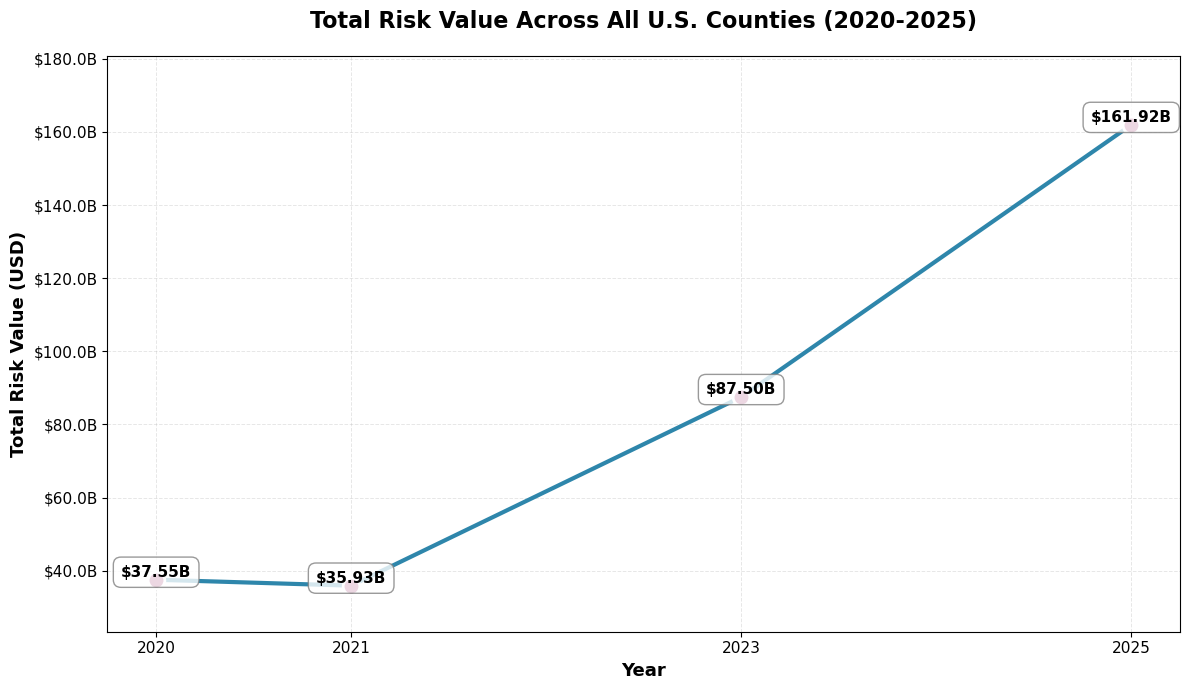

In [59]:
# Calculate total risk for each year
total_risk = {
    2020: risk_df['risk_val_2020'].sum(),
    2021: risk_df['risk_val_2021'].sum(),
    2023: risk_df['risk_val_2023'].sum(),
    2025: risk_df['risk_val_2025'].sum()
}

# Convert to lists for plotting
years = list(total_risk.keys())
total_risk = list(total_risk.values())

plt.figure(figsize=(12, 7))

# Plot the line
plt.plot(years, total_risk, 
         marker='o',           # Circle markers at each point
         markersize=12,        # Size of markers
         linewidth=3,          # Thickness of line
         color='#2E86AB',      # Nice blue color
         markerfacecolor='#A23B72',  # Different color for markers
         markeredgewidth=2,
         markeredgecolor='white')

# Add value labels on each point
for year, value in zip(years, total_risk):
    plt.text(year, value, 
             f'${value/1e9:.2f}B',  # Format as billions
             ha='center', 
             va='bottom',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# Styling
plt.title('Total Risk Value Across All U.S. Counties (2020-2025)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total Risk Value (USD)', fontsize=13, fontweight='bold')

# Format y-axis to show billions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B'))

# Add grid for readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Set x-axis to only show our years
plt.xticks(years, fontsize=11)
plt.yticks(fontsize=11)

# Add some padding to y-axis
y_range = max(total_risk) - min(total_risk)
plt.ylim(min(total_risk) - y_range*0.1, max(total_risk) + y_range*0.15)

# Tight layout
plt.tight_layout()

plt.show()

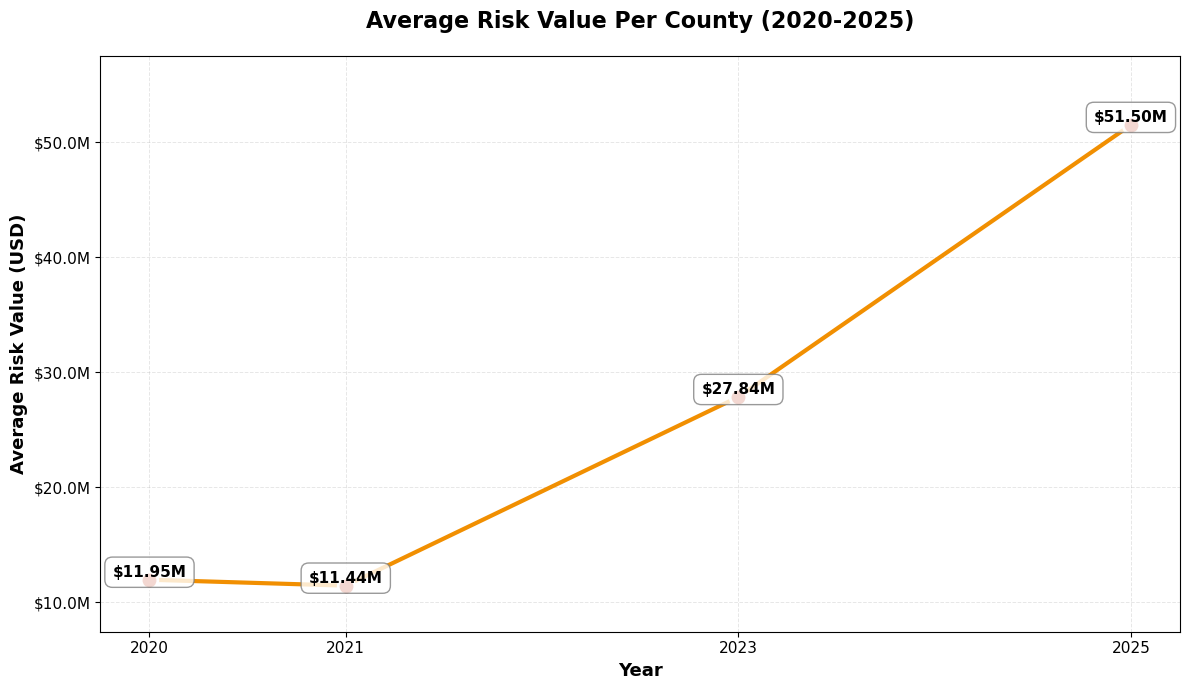

In [60]:
avg_risk_by_year = {
    2020: risk_df['risk_val_2020'].mean(),
    2021: risk_df['risk_val_2021'].mean(),
    2023: risk_df['risk_val_2023'].mean(),
    2025: risk_df['risk_val_2025'].mean()
}

years_avg = list(avg_risk_by_year.keys())
avg_risk = list(avg_risk_by_year.values())

plt.figure(figsize=(12, 7))
plt.plot(years_avg, avg_risk, 
         marker='o',
         markersize=12,
         linewidth=3,
         color='#F18F01',      # Orange color
         markerfacecolor='#C73E1D',
         markeredgewidth=2,
         markeredgecolor='white')

# Add value labels
for year, value in zip(years_avg, avg_risk):
    plt.text(year, value, 
             f'${value/1e6:.2f}M',  # Format as millions
             ha='center', 
             va='bottom',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.title('Average Risk Value Per County (2020-2025)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Average Risk Value (USD)', fontsize=13, fontweight='bold')

# Format y-axis to show millions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.xticks(years_avg, fontsize=11)
plt.yticks(fontsize=11)

y_range = max(avg_risk) - min(avg_risk)
plt.ylim(min(avg_risk) - y_range*0.1, max(avg_risk) + y_range*0.15)

plt.tight_layout()
plt.show()

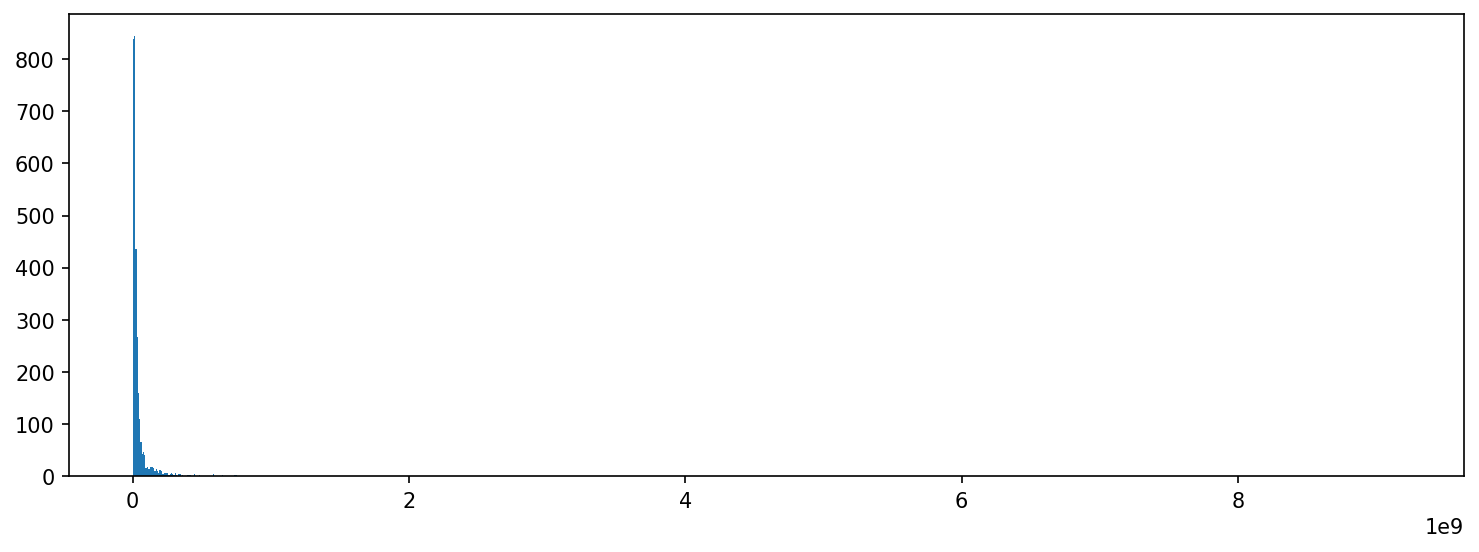

In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ymin,ymax = ax.get_ylim() 

ax.hist(nri_25.risk_value, bins=1000)
ax.vlines(x=nri_25.risk_value.mean(),ymin=ymin,ymax=ymax,colors='r',linestyles='--',label='Avg')
plt.show()

In [81]:
# pd.options.display.float_format = '{:,.2f}'.format
#nri_25.risk_value = nri_25.risk_value.round(2)
nri_25.style.format({"risk_value": "{:,}"})
nri_25[nri_25['risk_value'] > 1000000000].sort_values('risk_value',ascending=False)

# nri_25['risk_value' > 1000000000]


,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value
3021,C06037,CA,Los Angeles,10005712,"1,703,724,947,920.00","199,072,663.00","4,797.38","9,180,158,357.60",100.00,Very High,100.00,"7,601,846,373.16",Very High,55.38,Relatively Moderate,13.55,Very Low,2.35,1.21
2254,C17031,IL,Cook,5272775,"1,002,575,627,463.00","25,352,865.00","1,651.14","2,957,063,119.42",99.97,Very High,99.97,"2,424,304,449.02",Very High,61.74,Relatively High,73.28,Relatively High,2.55,1.22
2555,C48201,TX,Harris,4726200,"838,838,945,279.00","65,130,587.00","1,795.34","2,947,094,007.15",99.94,Very High,99.91,"2,217,702,382.78",Very High,67.94,Relatively High,17.88,Very Low,2.36,1.33
3024,C06065,CA,Riverside,2416838,"470,055,458,576.00","1,200,000,752.00","7,376.81","2,304,891,315.00",99.90,Very High,99.94,"2,265,637,642.99",Very High,33.33,Relatively Low,13.04,Very Low,2.34,1.02
3010,C04013,AZ,Maricopa,4418836,"854,730,526,869.00","1,556,808,461.00","9,319.14","2,118,483,387.32",99.87,Very High,99.88,"2,195,561,910.06",Very High,27.10,Relatively Low,18.03,Very Low,2.37,0.96
3025,C06071,CA,San Bernardino,2179979,"423,886,169,656.00","481,450,205.00","20,308.30","2,104,012,031.89",99.84,Very High,99.85,"2,075,099,788.96",Very High,33.21,Relatively Low,20.07,Relatively Low,2.37,1.01
2620,C06059,CA,Orange,3183647,"606,399,782,637.00","106,232,076.00",959.30,"1,822,511,759.81",99.81,Very High,99.78,"1,926,466,710.37",Very High,24.94,Relatively Low,16.32,Very Low,2.36,0.95
2208,C06001,CA,Alameda,1678284,"373,356,820,346.00","59,439,333.00",829.50,"1,776,525,270.88",99.78,Very High,99.75,"1,884,810,318.99",Very High,27.48,Relatively Low,91.16,Very High,2.63,0.94
2219,C06085,CA,Santa Clara,1934625,"428,353,306,701.00","399,381,703.00","1,317.22","1,686,687,111.82",99.75,Very High,99.81,"1,965,273,927.89",Very High,17.24,Very Low,72.61,Relatively High,2.55,0.86
3026,C06073,CA,San Diego,3295981,"638,825,464,234.00","1,070,494,224.00","4,571.49","1,462,271,163.08",99.71,Very High,99.69,"1,539,181,273.08",Very High,24.81,Relatively Low,8.30,Very Low,2.30,0.95


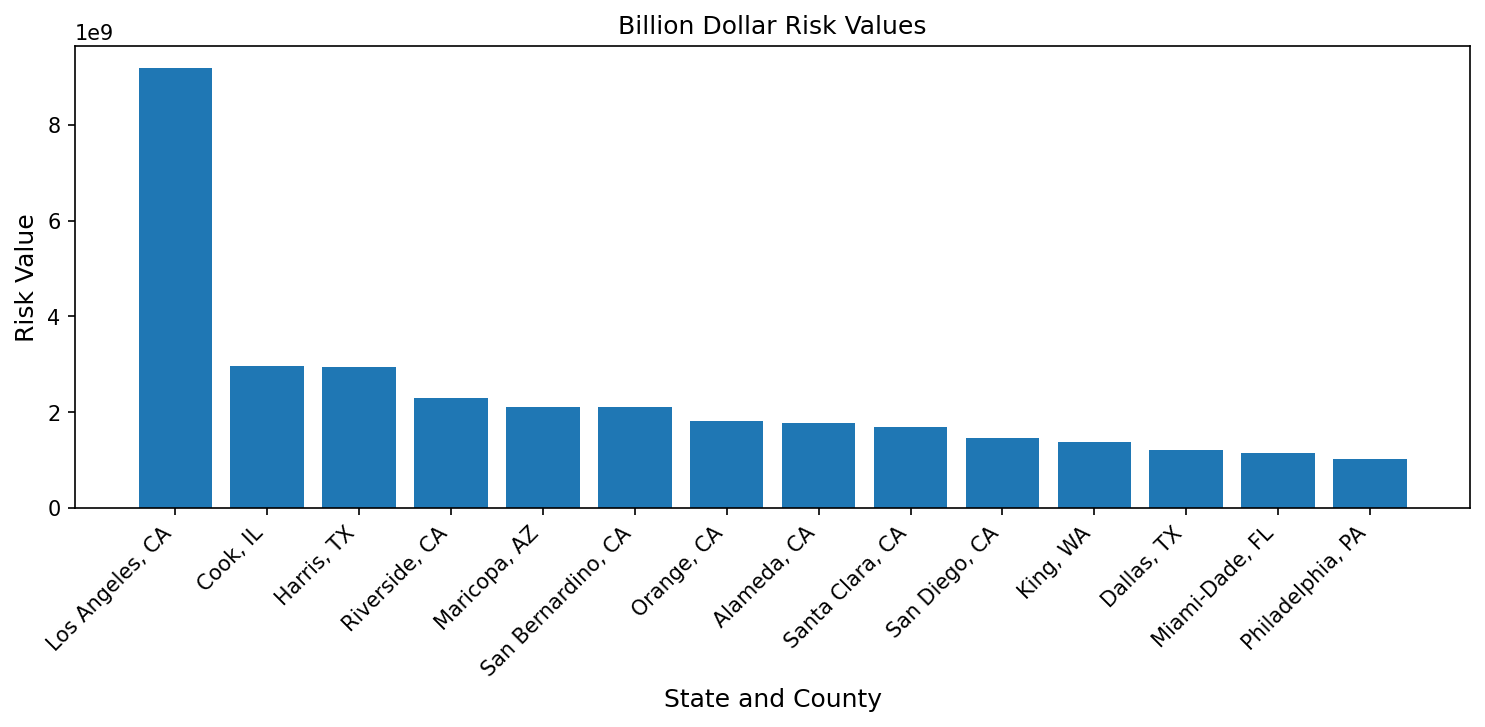

In [82]:
bil_25 = nri_25[nri_25['risk_value'] > 1000000000].sort_values('risk_value',ascending=False)
bil_25['county_state'] = bil_25.county + ', ' + bil_25.stateabbrv
# bil_25.risk_value.plot(kind='bar')

plt.figure(figsize=(12, 4), dpi=150)
plt.bar(bil_25['county_state'],bil_25.risk_value, linewidth=2)
plt.xticks(rotation=45,ha='right')
plt.title("Billion Dollar Risk Values")
plt.ylabel("Risk Value", fontsize=12)
plt.xlabel("State and County", fontsize=12)
plt.show()

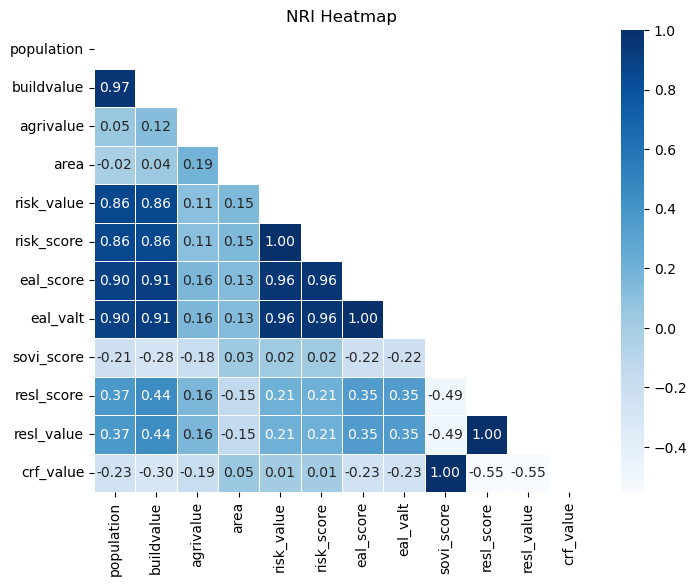

In [83]:
import numpy as np

correlation_matrix = nri_25.corr(method='spearman',numeric_only=True) # numeric_only=True to handle non-numeric columns
correlation_matrix

mask = np.ones_like(correlation_matrix, dtype=bool)
mask = np.triu(mask)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, mask=mask)
plt.title('NRI Heatmap')
plt.show()

To Dave: County by year with risk, resilience, eal, sovi
- what goes into resilience value/score, sovi value/score (census questions- look at technical doc), risk factor separately
- Sovi: score only nat'l percentile
- Resil: index factor
- Community Resil Factor: sovi/resil 

In [ ]:
sovi = nri_25.sovi_score.describe()
resl = nri_25.resl_value.describe()
resl2 = nri_25.resl_score.describe()
crf = nri_25.crf_value.describe()
resil = pd.concat([sovi,resl2,resl,crf],axis=1)
resil

,sovi_score,resl_score,resl_value,crf_value
count,"3,144.00","3,144.00","3,144.00","3,144.00"
mean,50.62,50.02,2.47,1.17
std,28.00,28.87,0.12,0.31
min,10.62,0.03,1.86,0.52
25%,25.05,25.02,2.39,0.93
50%,50.03,50.02,2.48,1.13
75%,75.03,75.01,2.56,1.39
max,100.00,100.00,2.88,2.00


In [75]:
sovi = nri_20.sovi_score.describe()
resl = nri_20.resl_value.describe()
crf = nri_20.crf_value.describe()
resil = pd.concat([sovi,resl,crf],axis=1)
resil

,sovi_score,resl_value,crf_value
count,3142.0,3142.0,3142.000000
mean,38.352501,2.729678,1.166906
std,11.148467,0.146987,0.311924
min,0.01,2.05947,0.515450
25%,31.888057,2.63243,0.933219
50%,38.352385,2.732885,1.134112
75%,44.461963,2.83729,1.387725
max,100.0,3.23368,2.000000


In [76]:
nri_25.head()

,nri_id,stateabbrv,county,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_ratng,eal_score,eal_valt,eal_ratng,sovi_score,sovi_ratng,resl_score,resl_ratng,resl_value,crf_value,st_county
0,C06075,CA,San Francisco,873808,173852174526.0,42355903.0,234.255013,915983769.771988,99.522901,Very High,99.597772,853429992.674755,Relatively High,48.059796,Relatively Moderate,99.650127,Very High,2.807558,1.073297,CA_San Francisco
1,C08047,CO,Gilpin,5803,1799265140.0,291994.0,151.904533,3622102.357588,6.361323,Very Low,10.891089,4503801.519584,Very Low,12.754453,Very Low,79.293893,Relatively High,2.576268,0.804232,CO_Gilpin
2,C13011,GA,Banks,18018,3830670950.0,218299789.0,236.772855,5617884.832526,12.40458,Very Low,17.079208,5943369.970484,Very Low,24.80916,Relatively Low,14.631043,Very Low,2.35043,0.945236,GA_Banks
3,C13013,GA,Barrow,83288,13453179051.0,46300672.0,164.577075,15107820.303437,45.610687,Relatively Low,57.054455,18174614.757267,Relatively Low,14.058524,Very Low,35.305344,Relatively Low,2.428901,0.831259,GA_Barrow
4,C13023,GA,Bleckley,12537,2524500231.0,15968067.0,221.343543,8981662.601893,25.667939,Very Low,19.956683,6599599.390071,Very Low,74.300254,Relatively High,52.703562,Relatively Moderate,2.486565,1.360941,GA_Bleckley


In [ ]:
# Select columns, create year column
core_25 = nri_25[['nri_id', 'stateabbrv', 'county','risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_25['year'] = 2025
core_23 = nri_23[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_23['year'] = 2023
core_21 = nri_21[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_21['year'] = 2021
core_20 = nri_20[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
core_20['year'] = 2020

core_df_long = pd.concat([core_20, core_21, core_23, core_25], 
                         ignore_index=True)
core_df_long = core_df_long.sort_values(['stateabbrv', 'county', 'year']).reset_index(drop=True)

print(core_df_long.shape)
core_df_long.head()

(12571, 9)


,nri_id,risk_value,eal_valt,sovi_score,resl_score,crf_value,year,stateabbrv,county
0,C02013,7932345.573781,4084185.513123,99.90458,0.731552,1.94221,2025,AK,Aleutians East
1,C02016,27540754.219547,29252953.548936,22.041985,0.477099,0.941469,2025,AK,Aleutians West
2,C02020,289559132.613365,366826354.062084,11.386768,34.796438,0.789363,2025,AK,Anchorage
3,C02050,14630146.787542,8285447.642992,99.968193,39.058524,1.765764,2025,AK,Bethel
4,C02060,1523512.486755,1390774.225629,43.956743,29.293893,1.095442,2025,AK,Bristol Bay


In [84]:
# Select columns
corew_25 = nri_25[['nri_id', 'stateabbrv', 'county','risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_23 = nri_23[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_21 = nri_21[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()
corew_20 = nri_20[['nri_id', 'risk_value', 'eal_valt', 'sovi_score', 'resl_score', 'crf_value']].copy()

# rename columns
corew_25.rename(columns={'risk_value': 'risk_val_2025',
                        'eal_valt': 'eal_valt_2025',
                        'sovi_score': 'sovi_score_2025',
                        'resl_score': 'resl_score_2025',
                        'crf_value': 'crf_value_2025'}, inplace=True)
corew_23.rename(columns={'risk_value': 'risk_val_2023',
                        'eal_valt': 'eal_valt_2023',
                        'sovi_score': 'sovi_score_2023',
                        'resl_score': 'resl_score_2023',
                        'crf_value': 'crf_value_2023'}, inplace=True)
corew_21.rename(columns={'risk_value': 'risk_val_2021',
                        'eal_valt': 'eal_valt_2021',
                        'sovi_score': 'sovi_score_2021',
                        'resl_score': 'resl_score_2021',
                        'crf_value': 'crf_value_2021'}, inplace=True)
corew_20.rename(columns={'risk_value': 'risk_val_2020',
                        'eal_valt': 'eal_valt_2020',
                        'sovi_score': 'sovi_score_2020',
                        'resl_score': 'resl_score_2020',
                        'crf_value': 'crf_value_2020'}, inplace=True)

core_df_wide = (corew_25
            .merge(corew_23, on='nri_id', how='outer')
            .merge(corew_21, on='nri_id', how='outer')
            .merge(corew_20, on='nri_id', how='outer'))

# add CT and AK county changes to fill in missing data and drop old counties
print(core_df_wide.shape)
core_df_wide.head()

(3153, 23)


,nri_id,stateabbrv,county,risk_val_2025,eal_valt_2025,sovi_score_2025,resl_score_2025,crf_value_2025,risk_val_2023,eal_valt_2023,sovi_score_2023,resl_score_2023,crf_value_2023,risk_val_2021,eal_valt_2021,sovi_score_2021,resl_score_2021,crf_value_2021,risk_val_2020,eal_valt_2020,sovi_score_2020,resl_score_2020,crf_value_2020
0,C01001,AL,Autauga,20510899.445224,19756570.050851,38.040712,55.120865,1.038181,6156054.321905,5514046.887245,51.299999,51.810001,1.116431,2087422.571669,2656700.419944,25.857312,55.5298,0.785720,2602011.52083,3311627.0725,25.857312,55.5298,0.785720
1,C01003,AL,Baldwin,253268743.625699,237391154.814839,44.243003,93.002545,1.066884,210632685.032046,202015117.825356,31.030001,86.120003,1.042658,11904921.522966,11792728.486542,34.292471,54.759202,1.009514,18341433.709805,18168582.4116,34.292471,54.759202,1.009514
2,C01005,AL,Barbour,15998575.833404,8923878.028715,96.374046,11.164122,1.792783,7412839.616804,4715303.672074,99.269997,6.24,1.572081,3905696.175216,3533815.684268,34.686638,50.781998,1.105235,3329979.822952,3012916.10989,34.686638,50.781998,1.105235
3,C01007,AL,Bibb,12672466.906524,8993704.310008,75.254453,22.169211,1.409038,3863746.994427,3164980.647954,80.779999,19.73,1.220781,1282439.441142,1756286.829243,21.482065,51.8076,0.730199,1564590.180265,2142689.18953,21.482065,51.8076,0.730199
4,C01009,AL,Blount,28705360.233474,21294673.675461,69.338422,15.648855,1.348007,10238536.291474,8509278.926663,51.369999,22.82,1.20322,5418308.436633,5954617.396941,29.720142,53.3574,0.909934,4141448.656626,4551372.90682,29.720142,53.3574,0.909934


In [85]:
core_df_long.to_csv("NRI_Long.csv", index=True)
core_df_wide.to_csv("NRI_Wide.csv", index=True)